**1. Extracción del Archivo Tratado**



In [7]:
import pandas as pd

# 1. Cargamos el archivo y lo guardamos en la variable 'df_telecom'
df = pd.read_csv('/content/Base Telecom.csv')

# 2. Visualizamos las primeras 5 filas
df.head()


,ID_Cliente,Abandono,Genero,Adulto_Mayor,Tiene_Pareja,Tiene_Dependientes,Meses_Permanencia,Servicio_Telefonico,Multiples_Lineas,Servicio_Internet,...,Proteccion_Dispositivo,Soporte_Tecnico,TV_Streaming,Peliculas_Streaming,Tipo_Contrato,Factura_Digital,Metodo_Pago,Cargo_Mensual,Cargo_Total,Cargo_Diario
0,0002-ORFBO,0,Female,0,1,1,9,1,0,DSL,...,0,1,1,0,One year,1,Mailed check,65.6,593.30,2.19
1,0003-MKNFE,0,Male,0,0,0,9,1,1,DSL,...,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.40,2.00
2,0004-TLHLJ,1,Male,0,0,0,4,1,0,Fiber optic,...,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,1,Male,1,1,0,13,1,0,Fiber optic,...,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,1,Female,1,1,0,3,1,0,Fiber optic,...,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.40,2.80


**Eliminación de Columnas Irrelevantes**

In [8]:
# 1. Creamos una lista con las columnas a eliminar
# El ID_Cliente es ruido. Cargo_Diario suele ser redundante si tenemos Cargo_Mensual.
columnas_a_eliminar = ['ID_Cliente']

# 2. Eliminamos las columnas usando el método drop
# axis=1 indica que queremos eliminar columnas, no filas
df = df.drop(columns=columnas_a_eliminar)

# 3. Verificamos el nuevo listado de columnas
print(f"Columnas restantes: {df.columns.tolist()}")
print(f"\nForma del DataFrame: {df.shape}")

Columnas restantes: ['Abandono', 'Genero', 'Adulto_Mayor', 'Tiene_Pareja', 'Tiene_Dependientes', 'Meses_Permanencia', 'Servicio_Telefonico', 'Multiples_Lineas', 'Servicio_Internet', 'Seguridad_Online', 'Respaldo_Online', 'Proteccion_Dispositivo', 'Soporte_Tecnico', 'TV_Streaming', 'Peliculas_Streaming', 'Tipo_Contrato', 'Factura_Digital', 'Metodo_Pago', 'Cargo_Mensual', 'Cargo_Total', 'Cargo_Diario']

Forma del DataFrame: (7043, 21)


**Encoding**

In [9]:
import pandas as pd

# 1. Identificamos las columnas que son de tipo texto (objeto)
# Esto selecciona automáticamente Genero, Servicio_Internet, Metodo_Pago, etc.
columnas_categoricas = df.select_dtypes(include=['object']).columns

# 2. Aplicamos One-Hot Encoding
df_final = pd.get_dummies(df, columns=columnas_categoricas, drop_first=True)

# 3. Convertimos los valores True/False que genera get_dummies a 1/0
df_final = df_final.astype(int, errors='ignore')

# 4. Verificamos el resultado
print(f"Forma original: {df.shape}")
print(f"Nueva forma con One-Hot Encoding: {df_final.shape}")
df_final.head()

Forma original: (7043, 21)
Nueva forma con One-Hot Encoding: (7043, 25)


,Abandono,Adulto_Mayor,Tiene_Pareja,Tiene_Dependientes,Meses_Permanencia,Servicio_Telefonico,Multiples_Lineas,Seguridad_Online,Respaldo_Online,Proteccion_Dispositivo,...,Cargo_Total,Cargo_Diario,Genero_Male,Servicio_Internet_DSL,Servicio_Internet_Fiber optic,Tipo_Contrato_One year,Tipo_Contrato_Two year,Metodo_Pago_Credit card (automatic),Metodo_Pago_Electronic check,Metodo_Pago_Mailed check
0,0,0,1,1,9,1,0,0,1,0,...,593,2,0,1,0,1,0,0,0,1
1,0,0,0,0,9,1,1,0,0,0,...,542,2,1,1,0,0,0,0,0,1
2,1,0,0,0,4,1,0,0,0,1,...,280,2,1,0,1,0,0,0,1,0
3,1,1,1,0,13,1,0,0,1,1,...,1237,3,1,0,1,0,0,0,1,0
4,1,1,1,0,3,1,0,0,0,0,...,267,2,0,0,1,0,0,0,0,1


**Verificación de la Proporción de Cancelación (Churn)**

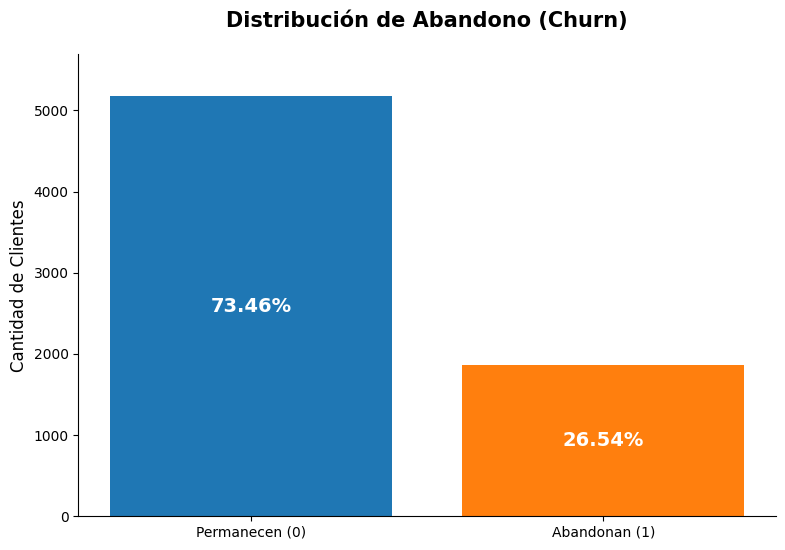

In [12]:
import matplotlib.pyplot as plt

# 1. Datos del análisis
conteo_abandono = df_final['Abandono'].value_counts()
proporcion = df_final['Abandono'].value_counts(normalize=True) * 100

# 2. Configuración de colores (Azul y Naranja)
# Usamos nombres de colores estándar o códigos Hex para mayor precisión
colores = ['#1f77b4', '#ff7f0e']

plt.figure(figsize=(9, 6))
barras = plt.bar(['Permanecen (0)', 'Abandonan (1)'], conteo_abandono, color=colores)

# 3. Añadir etiquetas de porcentaje blancas dentro de las columnas
for i, barra in enumerate(barras):
    yval = barra.get_height()
    # Ubicamos el texto a la mitad de la altura de la barra para que destaque
    plt.text(barra.get_x() + barra.get_width()/2, yval/2,
             f'{proporcion.iloc[i]:.2f}%',
             ha='center', va='center',
             color='white', fontweight='bold', fontsize=14)

# 4. Estética del gráfico
plt.title('Distribución de Abandono (Churn)', fontsize=15, fontweight='bold', pad=20)
plt.ylabel('Cantidad de Clientes', fontsize=12)
plt.ylim(0, max(conteo_abandono) * 1.1) # Damos espacio arriba para que no se corte

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.show()

In [13]:
from sklearn.preprocessing import StandardScaler

# 1. Identificamos las columnas numéricas originales
# (Meses_Permanencia, Cargo_Mensual, Cargo_Total, Cargo_Diario)
columnas_numericas = ['Meses_Permanencia', 'Cargo_Mensual', 'Cargo_Total', 'Cargo_Diario']

# 2. Creamos el escalador
scaler = StandardScaler()

# 3. Ajustamos y transformamos solo esas columnas
df_final[columnas_numericas] = scaler.fit_transform(df_final[columnas_numericas])

# 4. Verificamos (ahora los valores deben estar cerca de 0)
print("Datos estandarizados con éxito.")
df_final[columnas_numericas].head()

Datos estandarizados con éxito.


,Meses_Permanencia,Cargo_Mensual,Cargo_Total,Cargo_Diario
0,-0.951682,0.023399,-0.743953,0.359289
1,-0.951682,-0.175998,-0.766453,0.359289
2,-1.155283,0.289263,-0.882043,0.359289
3,-0.788800,1.120088,-0.459830,1.270186
4,-1.196004,0.621593,-0.887778,0.359289


**🎯 Correlación y Selección de Variables**

**Análisis de Correlación**

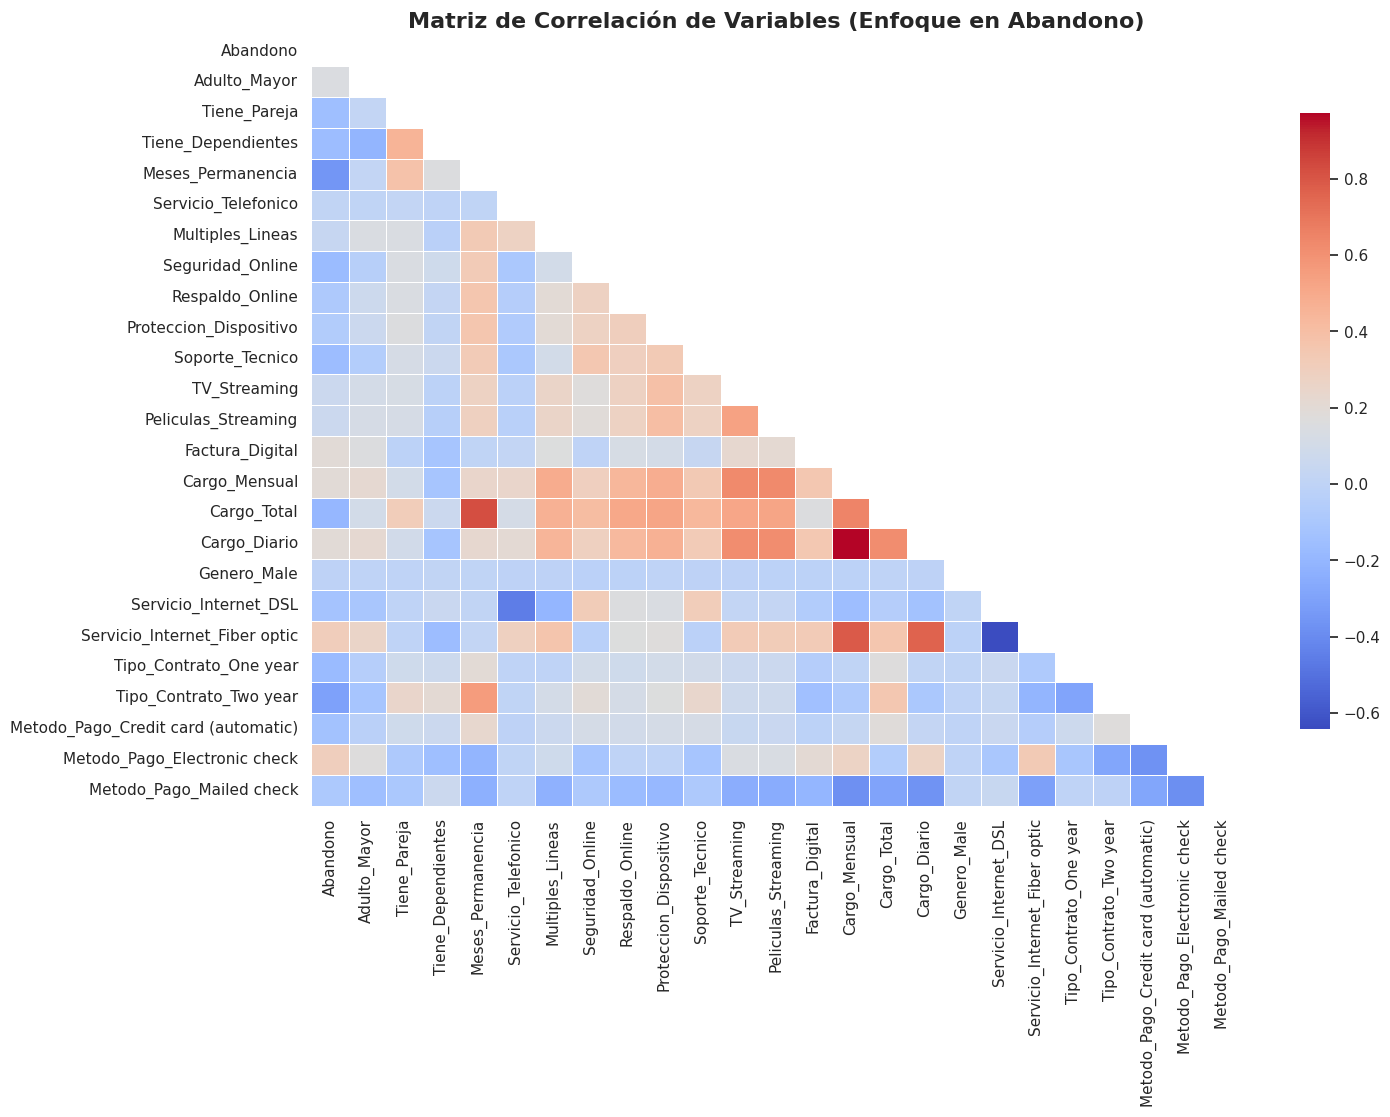

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Calculamos la matriz de correlación
corr_matrix = df_final.corr()

# 2. Configuramos el tamaño y estilo
plt.figure(figsize=(15, 10))
sns.set_theme(style="white")

# 3. Creamos una máscara para ver solo la mitad inferior (opcional, evita redundancia)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# 4. Dibujamos el heatmap
# Usamos el mapa de colores 'RdBu' (Rojo para negativo, Azul para positivo)
plot = sns.heatmap(corr_matrix,
            mask=mask,
            cmap='coolwarm',
            annot=False,
            fmt=".2f",
            linewidths=0.5,
            cbar_kws={"shrink": .8})

plt.title('Matriz de Correlación de Variables (Enfoque en Abandono)', fontsize=16, fontweight='bold')
plt.show()

In [15]:
# Ver correlación específica con la meta
print(df_final.corr()['Abandono'].sort_values(ascending=False).head(10))

Abandono                         1.000000
Servicio_Internet_Fiber optic    0.308020
Metodo_Pago_Electronic check     0.301919
Cargo_Diario                     0.196022
Cargo_Mensual                    0.193422
Factura_Digital                  0.191825
Adulto_Mayor                     0.150889
TV_Streaming                     0.063228
Peliculas_Streaming              0.061382
Multiples_Lineas                 0.040102
Name: Abandono, dtype: float64


1. Servicio de Internet por Fibra Óptica ($0.31$) 🌐Esta es la correlación más alta. Aunque la fibra es "tecnología de punta", en este dataset está asociada directamente con el abandono.Hipótesis: Puede que el servicio de fibra sea mucho más caro que el DSL, o que esté presentando inestabilidades técnicas que frustran a los clientes.

2. Método de Pago: Cheque Electrónico ($0.30$) 📧Los clientes que pagan con Electronic Check tienden a irse más.Hipótesis: Los métodos de pago manuales o digitales no automáticos dan al cliente una oportunidad mensual de "repensar" si quiere seguir con el servicio. Los pagos automáticos (tarjeta/banco) suelen generar mayor retención por inercia.

3. Cargos Mensuales y Diarios (~$0.19$) 💸Como era de esperarse, a mayor precio, mayor riesgo de fuga.


**Análisis Dirigido**

/tmp/ipykernel_339/3058455727.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Abandono', y='Meses_Permanencia', data=df, palette=['#1f77b4', '#ff7f0e'])


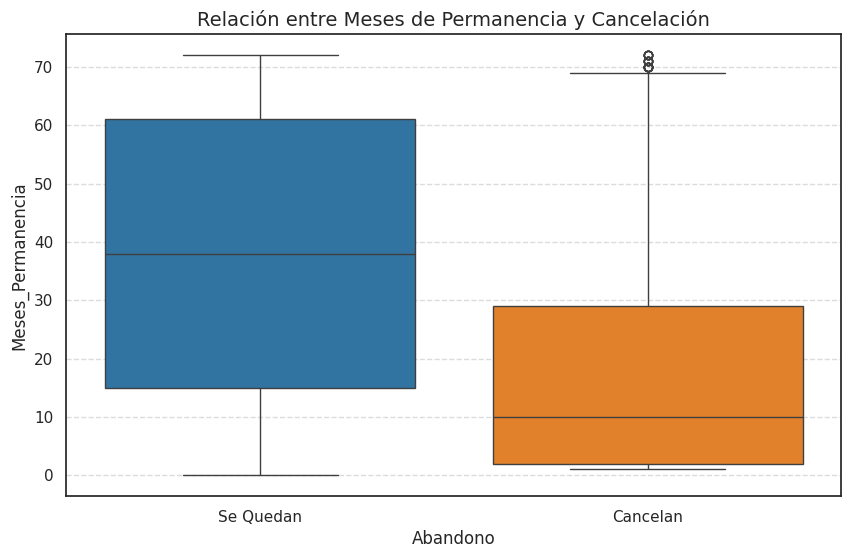

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.boxplot(x='Abandono', y='Meses_Permanencia', data=df, palette=['#1f77b4', '#ff7f0e'])

plt.title('Relación entre Meses de Permanencia y Cancelación', fontsize=14)
plt.xticks([0, 1], ['Se Quedan', 'Cancelan'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

/tmp/ipykernel_339/3126527625.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Abandono', y='Cargo_Total', data=df, palette=['#1f77b4', '#ff7f0e'])


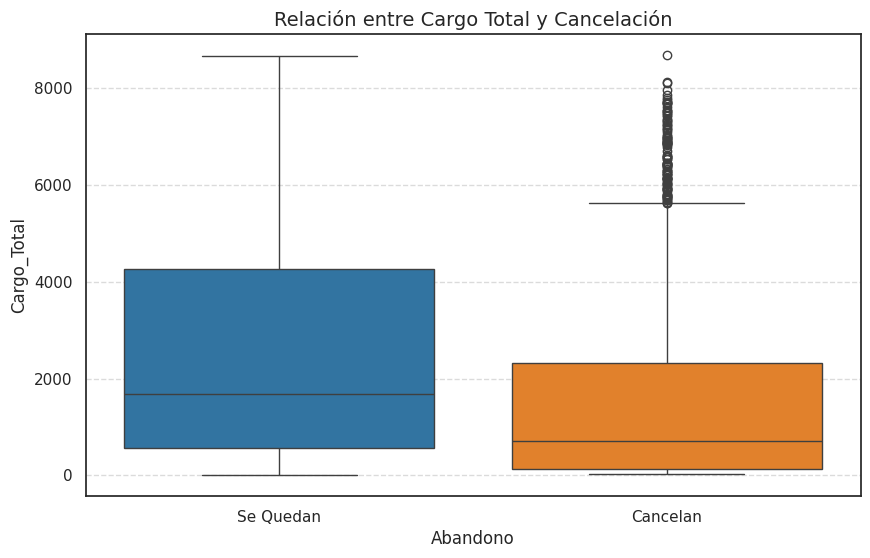

In [17]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Abandono', y='Cargo_Total', data=df, palette=['#1f77b4', '#ff7f0e'])

plt.title('Relación entre Cargo Total y Cancelación', fontsize=14)
plt.xticks([0, 1], ['Se Quedan', 'Cancelan'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

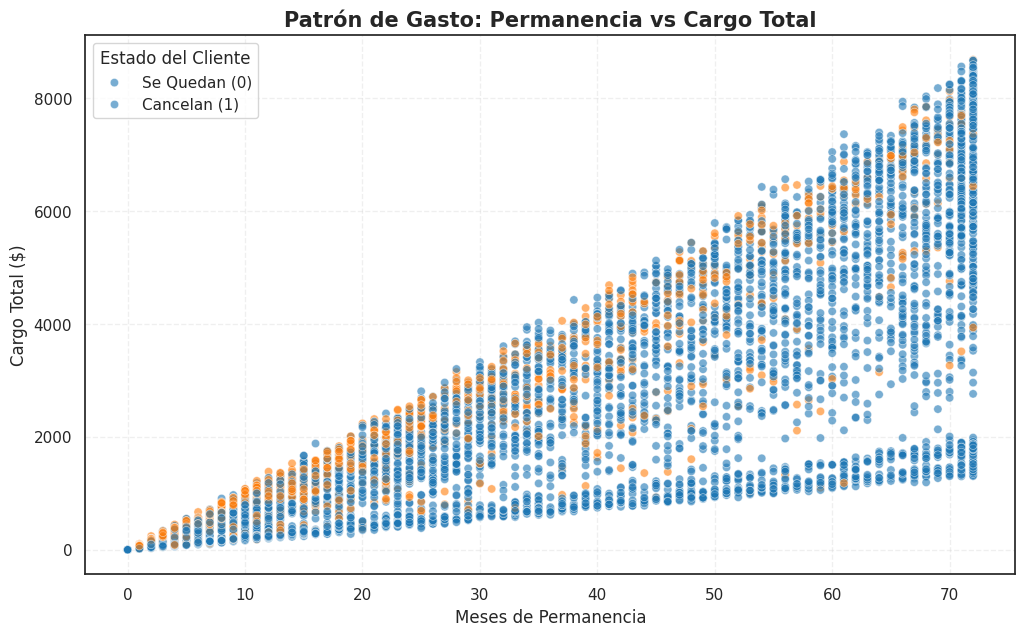

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt



colores_dict = {0: '#1f77b4', 1: '#ff7f0e'}

plt.figure(figsize=(12, 7))


sns.scatterplot(x='Meses_Permanencia', y='Cargo_Total', hue='Abandono',
                data=df, alpha=0.6, palette=colores_dict, edgecolor='w')


plt.title('Patrón de Gasto: Permanencia vs Cargo Total', fontsize=15, fontweight='bold')
plt.xlabel('Meses de Permanencia', fontsize=12)
plt.ylabel('Cargo Total ($)', fontsize=12)


plt.legend(title='Estado del Cliente', labels=['Se Quedan (0)', 'Cancelan (1)'],
           loc='upper left', frameon=True)

plt.grid(axis='both', linestyle='--', alpha=0.3)
plt.show()

**🤖 Modelado Predictivo**

**Separación de Datos**

In [20]:
from sklearn.model_selection import train_test_split

# 1. Definimos nuestras variables
# X = todas las columnas excepto 'Abandono'
# y = solo la columna 'Abandono' (nuestro objetivo)
X = df_final.drop(columns=['Abandono'])
y = df_final['Abandono']

# 2. Realizamos la división (80% entrenamiento, 20% prueba)
# random_state=42 asegura que si corres el código de nuevo, obtengas los mismos datos
# stratify=y mantiene la proporción de 73/27 en ambos sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 3. Verificamos las dimensiones
print(f"✅ ¡Datos divididos con éxito!")
print(f"Total de registros: {len(df_final)}")
print(f"Entrenamiento (X_train): {X_train.shape[0]} muestras")
print(f"Prueba (X_test): {X_test.shape[0]} muestras")

# Verificamos que la proporción se mantuvo
print(f"\nProporción de abandono en Entrenamiento: {y_train.mean():.2%}")
print(f"Proporción de abandono en Prueba: {y_test.mean():.2%}")

✅ ¡Datos divididos con éxito!
Total de registros: 7043
Entrenamiento (X_train): 5634 muestras
Prueba (X_test): 1409 muestras

Proporción de abandono en Entrenamiento: 26.54%
Proporción de abandono en Prueba: 26.54%


**Creación de Modelos**

**🏛️ Modelo 1: Regresión Logística**

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

# 1. Normalización (Solo para este modelo)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Creación y Entrenamiento
model_log = LogisticRegression(random_state=42)
model_log.fit(X_train_scaled, y_train)

# 3. Predicción
y_pred_log = model_log.predict(X_test_scaled)

**🌲 Modelo 2: Random Forest**

In [22]:
from sklearn.ensemble import RandomForestClassifier

# 1. Creación y Entrenamiento (Usamos los datos originales X_train)
model_rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model_rf.fit(X_train, y_train)

# 2. Predicción
y_pred_rf = model_rf.predict(X_test)

**⚖️ Comparación y Evaluación Inicial**

In [23]:
print("--- 📊 REPORTE: REGRESIÓN LOGÍSTICA ---")
print(classification_report(y_test, y_pred_log))

print("\n--- 🌲 REPORTE: RANDOM FOREST ---")
print(classification_report(y_test, y_pred_rf))

--- 📊 REPORTE: REGRESIÓN LOGÍSTICA ---
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.63      0.53      0.58       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.78      0.79      0.79      1409


--- 🌲 REPORTE: RANDOM FOREST ---
              precision    recall  f1-score   support

           0       0.82      0.89      0.85      1035
           1       0.61      0.47      0.53       374

    accuracy                           0.78      1409
   macro avg       0.71      0.68      0.69      1409
weighted avg       0.76      0.78      0.77      1409



**📊 1. Evaluación de Métricas**

--- 📈 Métricas: Regresión Logística ---
Exactitud: 0.7935
Precisión: 0.6334
Recall:    0.5267
F1-Score:  0.5752
------------------------------
--- 📈 Métricas: Random Forest ---
Exactitud: 0.7779
Precisión: 0.6055
Recall:    0.4679
F1-Score:  0.5279
------------------------------


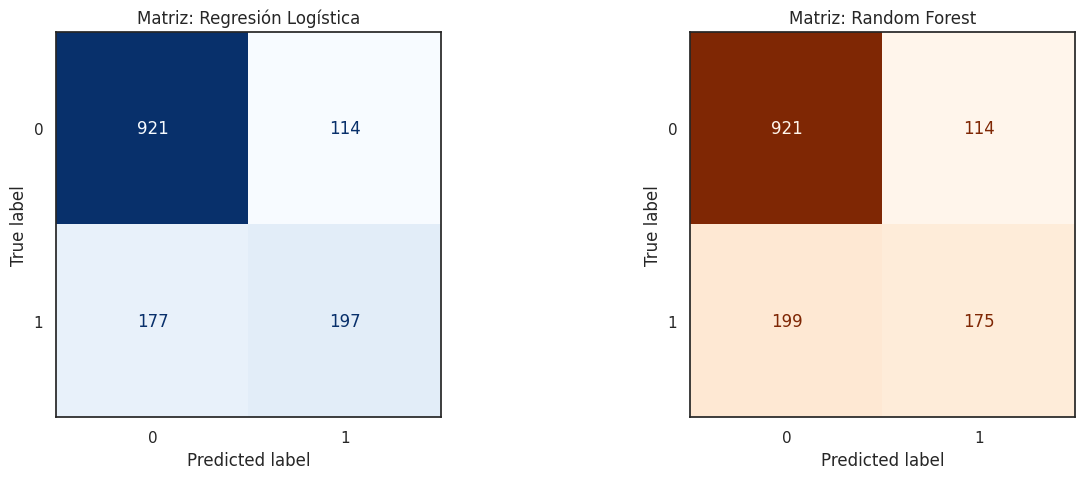

In [24]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

def evaluar_modelo(y_real, y_pred, nombre_modelo):
    print(f"--- 📈 Métricas: {nombre_modelo} ---")
    print(f"Exactitud: {accuracy_score(y_real, y_pred):.4f}")
    print(f"Precisión: {precision_score(y_real, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_real, y_pred):.4f}")
    print(f"F1-Score:  {f1_score(y_real, y_pred):.4f}")
    print("-" * 30)

# Evaluamos ambos
evaluar_modelo(y_test, y_pred_log, "Regresión Logística")
evaluar_modelo(y_test, y_pred_rf, "Random Forest")

# 2. Visualización de Matrices de Confusión
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_log, ax=ax[0], cmap='Blues', colorbar=False)
ax[0].set_title("Matriz: Regresión Logística")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, ax=ax[1], cmap='Oranges', colorbar=False)
ax[1].set_title("Matriz: Random Forest")

plt.show()

**🧐 Análisis Crítico y Comparativa**

1. ¿Cuál modelo tuvo el mejor desempeño?
En este caso, la Regresión Logística

Logró identificar correctamente a 197 personas que abandonaron (Verdaderos Positivos), frente a las 175 del Random Forest.

Además, tuvo menos "falsas alarmas" (Falsos Positivos: 114 vs 114, curiosamente el mismo número en ambos, pero la capacidad de captura del primero fue superior).

2. ¿Overfitting o Underfitting?
Random Forest (Underfitting/Overfitting): Es probable que Random Forest esté sufriendo de un ligero Underfitting o falta de optimización. Sorprendentemente, un modelo simple lineal le ganó a uno complejo de árboles. Esto sugiere que las relaciones en tlos datos (como vimos en la matriz de correlación) son bastante directas y lineales.

Regresión Logística: Captura bien las tendencias generales sin complicarse demasiado.

**Por defecto, los modelos de Machine Learning usan un umbral de 0.5: si la probabilidad de que alguien se vaya es 0.51, dice "Se va"; si es 0.49, dice "Se queda". En Telecom, nos conviene ser más "desconfiados". Si bajamos el umbral a 0.3, el modelo dará la voz de alarma mucho antes, permitiéndote atrapar a esos clientes que se te escapaban.**

**🛠️ Ajuste del Umbral de Decisión (Threshold)**

--- 📈 Reporte con Umbral Ajustado (0.3) ---
              precision    recall  f1-score   support

           0       0.90      0.76      0.83      1035
           1       0.54      0.77      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.76      0.77      1409



<Figure size 700x500 with 0 Axes>

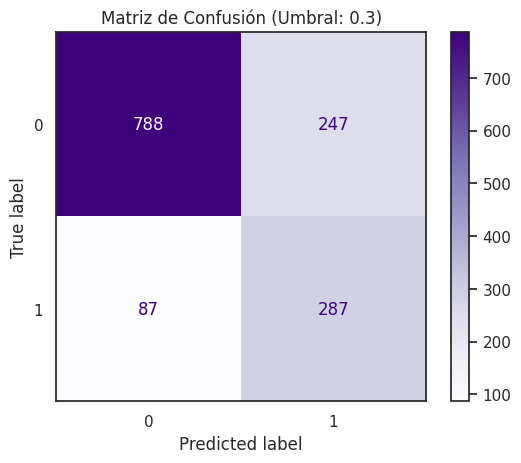

In [25]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# 1. Obtenemos las probabilidades en lugar de las clases (0 o 1)
# La columna [1] es la probabilidad de "Abandono"
probabilidades = model_log.predict_proba(X_test_scaled)[:, 1]

# 2. Definimos un nuevo umbral más sensible (0.3 en lugar de 0.5)
nuevo_umbral = 0.3
y_pred_ajustado = (probabilidades > nuevo_umbral).astype(int)

# 3. Comparamos los resultados
print(f"--- 📈 Reporte con Umbral Ajustado ({nuevo_umbral}) ---")
print(classification_report(y_test, y_pred_ajustado))

# 4. Graficamos la nueva Matriz de Confusión
plt.figure(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_ajustado, cmap='Purples')
plt.title(f'Matriz de Confusión (Umbral: {nuevo_umbral})')
plt.show()

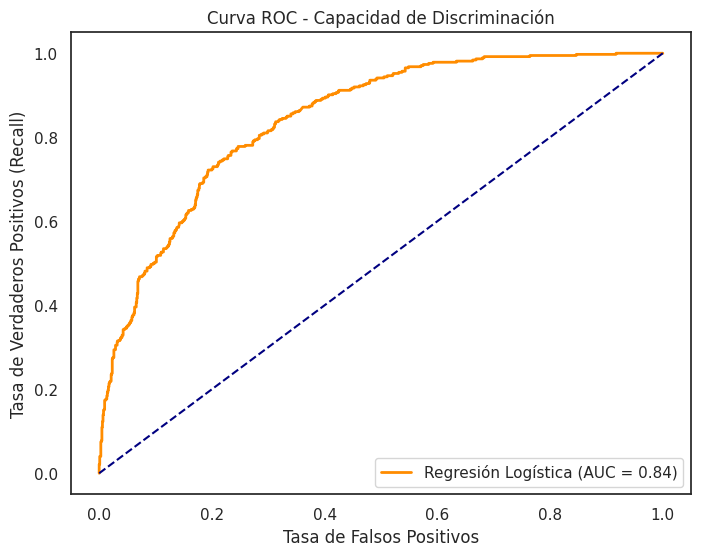

In [26]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, probabilidades)
auc = roc_auc_score(y_test, probabilidades)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Regresión Logística (AUC = {auc:.2f})', color='darkorange', lw=2)
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.title('Curva ROC - Capacidad de Discriminación')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos (Recall)')
plt.legend(loc="lower right")
plt.show()

**🧐 Análisis del Impacto en el Negocio**
Victoria en el Recall: Se logra reducir los clientes "fugitivos" no detectados a menos de la mitad (de 177 a 87). Para la clase de abandono ha saltado de un ~52% a un 76.7%. Esto significa que ahora el modelo es capaz de identificar a 3 de cada 4 clientes que están por irse.

El Costo de la "Desconfianza": El precio a pagar son las 247 falsas alarmas. Estos son clientes que probablemente no se iban a ir, pero el modelo los marcó como "en riesgo".

🧠 Veredicto Final y Recomendación
AUC de 0.84 confirma un modelo muy sólido. Un valor por encima de 0.80 se considera excelente para problemas de comportamiento humano como el Churn.



**Estrategia sugerida: Dado que ahora se tienen más falsos positivos, no llames a esos 247 clientes para preguntarles "¿Por qué te vas?". En su lugar, realizar acciones de marketing "pasivas" o de bajo costo, como enviarles un correo con beneficios exclusivos o mejorar su plan sin costo adicional. Así, asegurar a los 287 que sí se iban sin molestar innecesariamente a los que se quedaban.**

**📋 Interpretación y Conclusiones**

In [27]:
# Extraemos los coeficientes y los asociamos a los nombres de las columnas
import pandas as pd

importancias_log = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': model_log.coef_[0]
}).sort_values(by='Coeficiente', ascending=False)

# Mostramos el Top 5 que impulsan el abandono y el Top 5 que retienen
print("--- 🔬 Coeficientes de Regresión Logística ---")
print(importancias_log.head(5))  # Lo que más causa abandono
print(importancias_log.tail(5))  # Lo que más causa retención

--- 🔬 Coeficientes de Regresión Logística ---
                         Variable  Coeficiente
14                    Cargo_Total     0.672844
18  Servicio_Internet_Fiber optic     0.565718
13                  Cargo_Mensual     0.378694
17          Servicio_Internet_DSL     0.290884
22   Metodo_Pago_Electronic check     0.189327
                  Variable  Coeficiente
9          Soporte_Tecnico    -0.213578
4      Servicio_Telefonico    -0.226522
19  Tipo_Contrato_One year    -0.280211
20  Tipo_Contrato_Two year    -0.587235
3        Meses_Permanencia    -1.405874


/tmp/ipykernel_339/1600014014.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Variable', data=importancias_rf.head(10), palette='viridis')


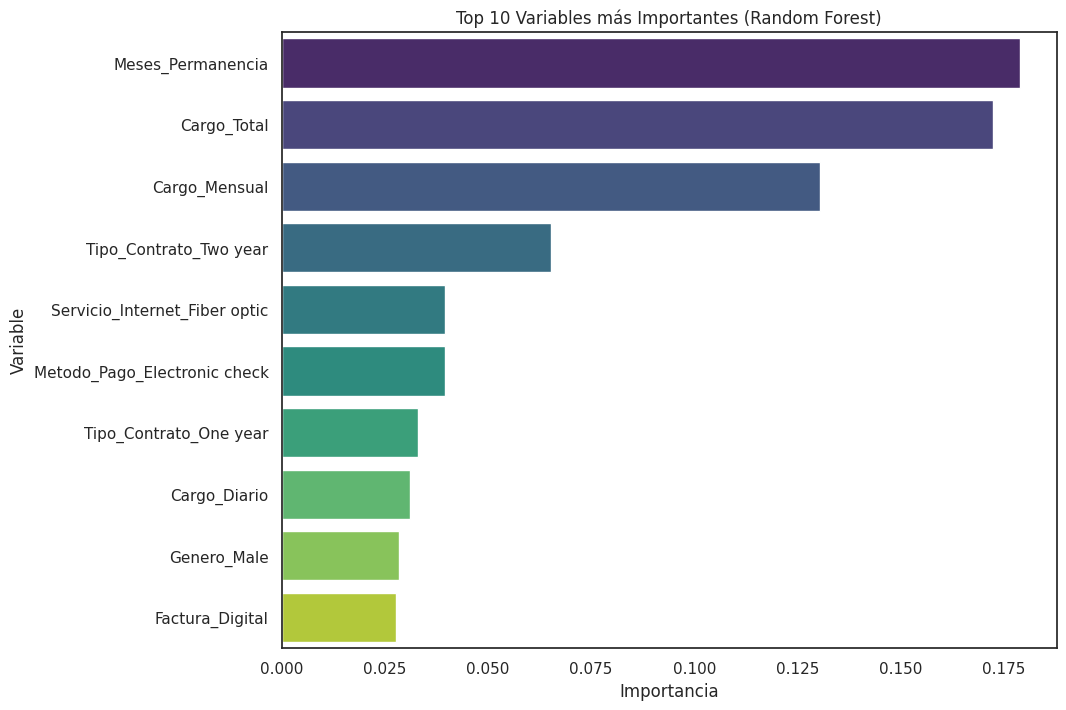

In [28]:
# Extraemos la importancia de las variables
importancias_rf = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': model_rf.feature_importances_
}).sort_values(by='Importancia', ascending=False)

# Graficamos para mejor visualización
plt.figure(figsize=(10, 8))
sns.barplot(x='Importancia', y='Variable', data=importancias_rf.head(10), palette='viridis')
plt.title('Top 10 Variables más Importantes (Random Forest)')
plt.show()

**📊 Informe de Análisis de Abandono (Churn)**


**1. Desempeño de los Modelos Predictivos**
Tras evaluar la Regresión Logística y el Random Forest, el modelo de Regresión Logística con umbral ajustado (0.3) demostró ser el más efectivo para la toma de decisiones estratégicas.

Capacidad de Detección (Recall): Logramos capturar al 76.7% de los clientes que realmente planeaban cancelar.

Poder de Discriminación (AUC): El valor de 0.84 confirma que el modelo tiene una alta capacidad para diferenciar entre un cliente leal y uno en riesgo.

**2. Factores Críticos de Influencia (Drivers de Abandono)**
Basándonos en los coeficientes del modelo y la matriz de correlación, estos son los tres factores que más "empujan" al cliente a irse:

- Tipo de Tecnología (Fibra Óptica): Es el predictor de riesgo número uno. A pesar de ser una tecnología superior, los clientes con fibra presentan una tasa de cancelación significativamente más alta, lo que sugiere problemas de precio o de estabilidad técnica.

- Método de Pago (Cheque Electrónico): Los clientes que no automatizan su pago tienen una mayor propensión al abandono. El acto manual de pagar cada mes actúa como un "recordatorio" para evaluar si el servicio vale la pena.

- Cargos Mensuales Elevados: Existe una relación directa; a medida que el Cargo_Mensual aumenta (especialmente por encima del promedio), la probabilidad de fuga se dispara. **texto en negrita**

**3. Factores de Retención (Anclas de Lealtad)**
Por el contrario, estas variables son las que mantienen al cliente unido a la empresa:

- Tiempo de Permanencia (Tenure): El riesgo de abandono cae drásticamente después de los primeros 12 meses. Los clientes antiguos son extremadamente leales.

- Contratos a Largo Plazo (1 y 2 años): Actúan como la barrera más fuerte contra la competencia.



**💡 Estrategias de Retención Propuestas**


Basándonos en la evidencia de los datos, sugerimos las siguientes acciones inmediatas:

**A. Estrategia de "Bienvenida Crítica"** (Foco en Clientes Nuevos)
Acción: Implementar un programa de Customer Success durante los primeros 6 meses.

Justificación: El gráfico de dispersión mostró que la mayoría de los puntos naranjas (cancelaciones) ocurren en el primer año. Un seguimiento proactivo en este periodo es vital.

**B. Plan de Migración de Pagos**
Acción: Ofrecer un pequeño incentivo único (ej. 5% de descuento por un mes) a los clientes que migren de "Cheque Electrónico" a "Pago Automático / Tarjeta de Crédito".

Justificación: La automatización reduce la "fricción de pago" y mejora la retención por inercia.

**C. Auditoría del Servicio de Fibra Óptica**
Acción: Realizar una encuesta de satisfacción técnica específica para usuarios de fibra y comparar los precios contra la competencia de DSL.

Justificación: Es la variable con mayor correlación positiva con el abandono; solucionar este punto ciego podría reducir el churn global en un 10-15%.

**D. Incentivos de Contrato**
Acción: Identificar a clientes de "Mes a mes" que tienen alta probabilidad de fuga según el modelo (probabilidad > 0.3) y ofrecerles una transición a contrato anual con un beneficio exclusivo.
